# Work for neuron analysis with NeuroVis pacakge

## Analysis focus: neurons who's soma are located in the Anterior insular cortex.

### Key references: 
- https://mouse.digital-brain.cn/projectome/ 
    - For direct visualisation of the data for comparison, and learning useful ways to analyse the data 
- 
Aim:

To compare the projection pattern of anterior cingulate and anterior insular cortex neurons.
To determine the interconnection of these two regions.

Planned Analysis flow:
1. Overall projection pattern:
    - What are the target regions?
    - Relative strength of the projections towards these regions?
2. Neuronal types
    - Clustering of the neurons based on projection, what are the types of neurons from different clusters?
3. Visulisation
    - Use the Visual module to generate illustrative figures for the analysis.

***
### **Actual workflow**:
1. Acquire list of neurons whose soma are located in the Anterior insular cortex.
    - filter problematic neurons
    - focus on the PT neurons (this is what I am interested in) -as they target the subcortical regions.
2. sort out those neuron who could project to subcortical nuclei, including PAG, parabrachial nuclei and NTS
3. visualise those neurons 

***


Current progress:
(tried on monkey data but the data were not ready, thus used mouse data)
1. Acquired neuronlist for those neurons whose soma are located in the Anterior insular cortex.

In [1]:
import sys,copy,os,inspect

import requests
from bs4 import BeautifulSoup

# path definition
neurovis_path = os.path.abspath(r'D:\Monkey_projectome_training\neuron-vis\neuronVis')
sys.path.append(neurovis_path)

# neuron_path = os.path.join(neurovis_path,"../resource/swc/192106/001.swc")
# sys.path.append(neuron_path)

import IONData
import SwcLoader


iondata = IONData.IONData()


# print(tree)


Remove the excluded neurons

- when looking at the returned neuronlist structure, I noticed a column called "excluded", with reference to the "comment" column, It should indicate if the neuron is excluded from the analysis or not.
- also, using the 'type' attribute I can get PT neurons.

In [2]:
ai_neuronlist = iondata.getNeuronListBySomaBrainRegion('AI')
# tree = iondata.getNeuronTreeByID(neuronlist[0]['sampleid'], neuronlist[0]['name'])
#

# print(ai_neuronlist)
# unique_regions = set(neuron['region'] for neuron in ai_neuronlist)

# # Convert set to a sorted list if needed
# unique_regions = sorted(unique_regions)
# filtered_neuronlist = [neuron for neuron in neuronlist if neuron.get('exclude') == '0' and neuron.get('type') == 'PT']
# print(len(filtered_neuronlist))


In [3]:

# iterative loading of the neurons 
# Print or use the filtered list
import os
import json

# Create directories if they don't exist
# os.makedirs('swc_files', exist_ok=True)
# os.makedirs('properties', exist_ok=True)

# for neuron in filtered_neuronlist:
#     try:
#         # Get neuron ID and SWC filename (adjust these keys according to your data structure)
#         neuron_id = neuron['id']
#         swc_filename = neuron['swc']  # Might be '001.swc' from your example
        
#         # Get SWC data and properties
#         swc_data = iondata.getNeuronByID(neuron_id, swc_filename)
#         properties = iondata.getNeuronPropertyByID(neuron_id, swc_filename)
       
#         neuron_data.append({
#             'id': neuron_id,
#             'swc_data': swc_data,
#             'properties': properties
#         })
        
       
#         print(f"Saved {neuron_id} successfully")
    
#     except Exception as e:
#         print(f"Error processing {neuron_id}: {str(e)}")



swc = iondata.getNeuronByID('194786', '001.swc')
pro = iondata.getNeuronPropertyByID('194786', '001.swc')
neuron_tree = SwcLoader.NeuronTree()
neuron_tree.readSWC(swc)
print(pro)

exist  D:\Monkey_projectome_training\neuron-vis\neuronVis/../resource/swc/194786/001.swc
{'Center': [2810.1484375, 4040.55078125, 3052.53515625], 'Depth': 8753.16015625, 'Height': 2134.33984375, 'MaxOrder': 17, 'N_bifs': 92, 'N_stems': 1, 'Width': 4032.0078125, 'axonlength': 58530.39453125, 'branchcount': 189, 'dendritelength': 0, 'doubleside': 1, 'endcount': 98, 'id': '1610', 'projectleftregion': {'ACAv1': 74.634933, 'ACAv2/3': 97.087761, 'ACAv5': 220.238464, 'ACAv6a': 156.518097, 'AId1': 261.255707, 'AId2/3': 10164.53418, 'AId5': 17002.117188, 'AId6a': 785.64978, 'AId6b': 55.941971, 'AIp1': 506.507416, 'AIp2/3': 4515.086914, 'AIp5': 980.32489, 'AIv5': 135.123016, 'GU1': 0, 'GU2/3': 1129.195557, 'GU4': 253.05307, 'GU5': 1573.417969, 'IG': 89.193558, 'MOp2/3': 0, 'MOp5': 0, 'MOp6a': 0, 'MOp6b': 0, 'MOs6b': 0, 'PIR': 1.622721, 'ccg': 30.279953, 'fa': 1306.407349, 'scwm': 95.848198}, 'projectregion': {'ACAv1': 129.610657, 'ACAv2/3': 194.419678, 'ACAv5': 419.228851, 'ACAv6a': 196.224045, 

In [4]:
neuron_tree.plotMPR('./neuron.png')

D:\Monkey_projectome_training\neuron-vis\neuronVis\SwcLoader.py:184: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(x, y,'g-',color='#FFFFFF')
D:\Monkey_projectome_training\neuron-vis\neuronVis\SwcLoader.py:203: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(x, y,'g-',color='#FFFFFF')
D:\Monkey_projectome_training\neuron-vis\neuronVis\SwcLoader.py:222: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(x, y,'g-',color='#FFFFFF')


neuron_tree.draw()   # draw the neuron tree

By looking at the returned Properties of the neuron, I think the axon length attribute is the parameter for projection length. So I will try to compare that.
- First extract the swc data and properties 

In [5]:
# roi_neurons= []
# for neuron in filtered_neuronlist:
#     # Get neuron ID and SWC filename (adjust these keys according to your data structure)
#     neuron_id = neuron['sampleid']
#     swc_filename = neuron['name']  # Might be '001.swc' from your example
    
#     # Get SWC data and properties
#     properties = iondata.getNeuronPropertyByID(neuron_id, swc_filename)
    
#     project_region = properties['projectregion']
    
#     rois = ['PB',"PAG","NTS"]
#     if any(roi in project_region for roi in rois):
#         roi_neurons.append(neuron)
    

 

In [6]:
swc

'1 1 2799.11633 4059.32748 3041.38694 2.5976562500000e+00 -1\n2 0 2798.99879 4057.83447 3041.27359 3.5000000000000e+00 1\n3 0 2798.6398 4052.73588 3041.15543 2.5390625000000e+00 2\n4 0 2798.8151 4052.60804 3042.37469 1.6914062500000e+00 3\n5 0 2800.57323 4052.69818 3046.07036 6.4062500000000e-01 4\n6 0 2802.81233 4052.49134 3046.68545 5.5468750000000e-01 5\n7 0 2805.43761 4052.14885 3047.16641 3.5156250000000e-01 6\n8 0 2806.16907 4050.84414 3048.18193 5.2343750000000e-01 7\n9 0 2806.65232 4048.85937 3048.97937 6.7187500000000e-01 8\n10 0 2808.13967 4046.94005 3049.52622 5.8203125000000e-01 9\n11 0 2809.7305 4045.36814 3050.00922 4.1015625000000e-01 10\n12 0 2810.0505 4043.74722 3050.60967 3.5156250000000e-01 11\n13 0 2810.14827 4040.55127 3052.53669 5.8203125000000e-01 12\n14 0 2810.47196 4037.41106 3054.15528 5.2343750000000e-01 13\n15 0 2811.36913 4035.37237 3055.26636 2.9296875000000e-01 14\n16 0 2811.69326 4033.10438 3056.89641 2.9296875000000e-01 15\n17 0 2812.73539 4031.25198 30

In [ ]:
import Visual as nv
'''
Basic Colors:

White: [1.0, 1.0, 1.0] (default)
Red: [1.0, 0.0, 0.0]
Green: [0.0, 1.0, 0.0]
Blue: [0.0, 0.0, 1.0]
Yellow: [1.0, 1.0, 0.0]
Cyan: [0.0, 1.0, 1.0]
Magenta: [1.0, 0.0, 1.0]
Black: [0.0, 0.0, 0.0]
Pastel Colors:

Pink: [1.0, 0.7, 0.7]
Lavender: [0.7, 0.7, 1.0]
Mint: [0.7, 1.0, 0.7]
Peach: [1.0, 0.9, 0.7]
Gray Scales:

Light Gray: [0.8, 0.8, 0.8]
Medium Gray: [0.5, 0.5, 0.5]
Dark Gray: [0.2, 0.2, 0.2]
'''

visualisation = nv.neuronVis()
visualisation.render.setBackgroundColor([0.0, 0.0, 0.0])
visualisation.addRegion('AI',[1.0, 1.0, 0.0])

# region file can be confirmed with the annot.txt file, 检查Visual可知。

# visualisation.addNeuronByList(roi_neurons[:5])

# neuronvis.render.savepng('test.png')
# visualisation.render.setView("posterior")
visualisation.render.setLookAt((-10000,-5000,-10000),(0,0,0),(0,-1,0))

# neuronvis.render.setLookAt()
# neuronvis.addNeuron(neurovis_path+'/../resource/192092-012.swc',[1.0,1.0,0.0])
# neuronvis.addNeuronByID('192106','011.swc',[1.0,1.0,0.0])
# neuronvis.render.savepng('test2.png')
visualisation.render.savepng('aic2subcortical_PT_neuron.png')

# interactive visualisation
visualisation.render.run()




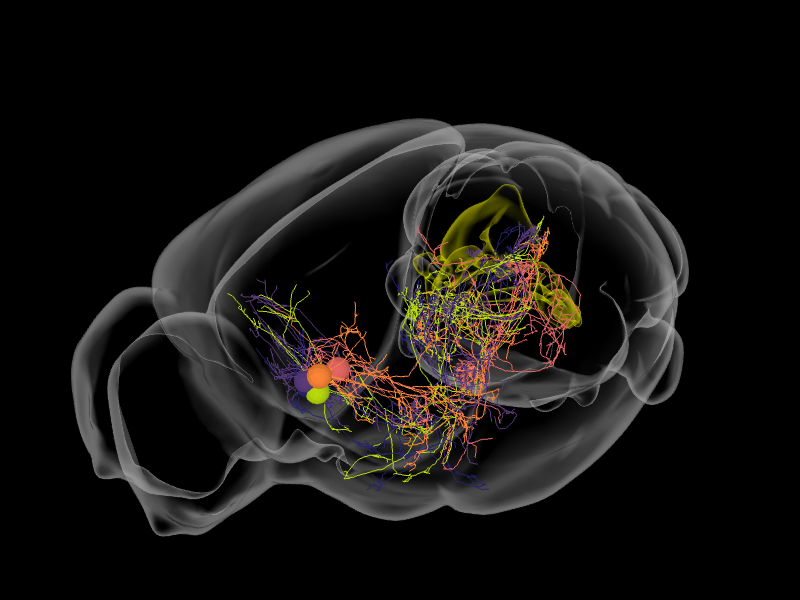

In [ ]:
from IPython.display import Image

# Display the image
Image(filename='aic2subcortical_PT_neuron.png')



In [ ]:
regionFileName=iondata.getFileFromServer('annot.txt')
print(regionFileName)

(True, 'D:\\Monkey_projectome_training\\neuron-vis\\neuronVis/../resource/annot.txt')


## Reading SWC
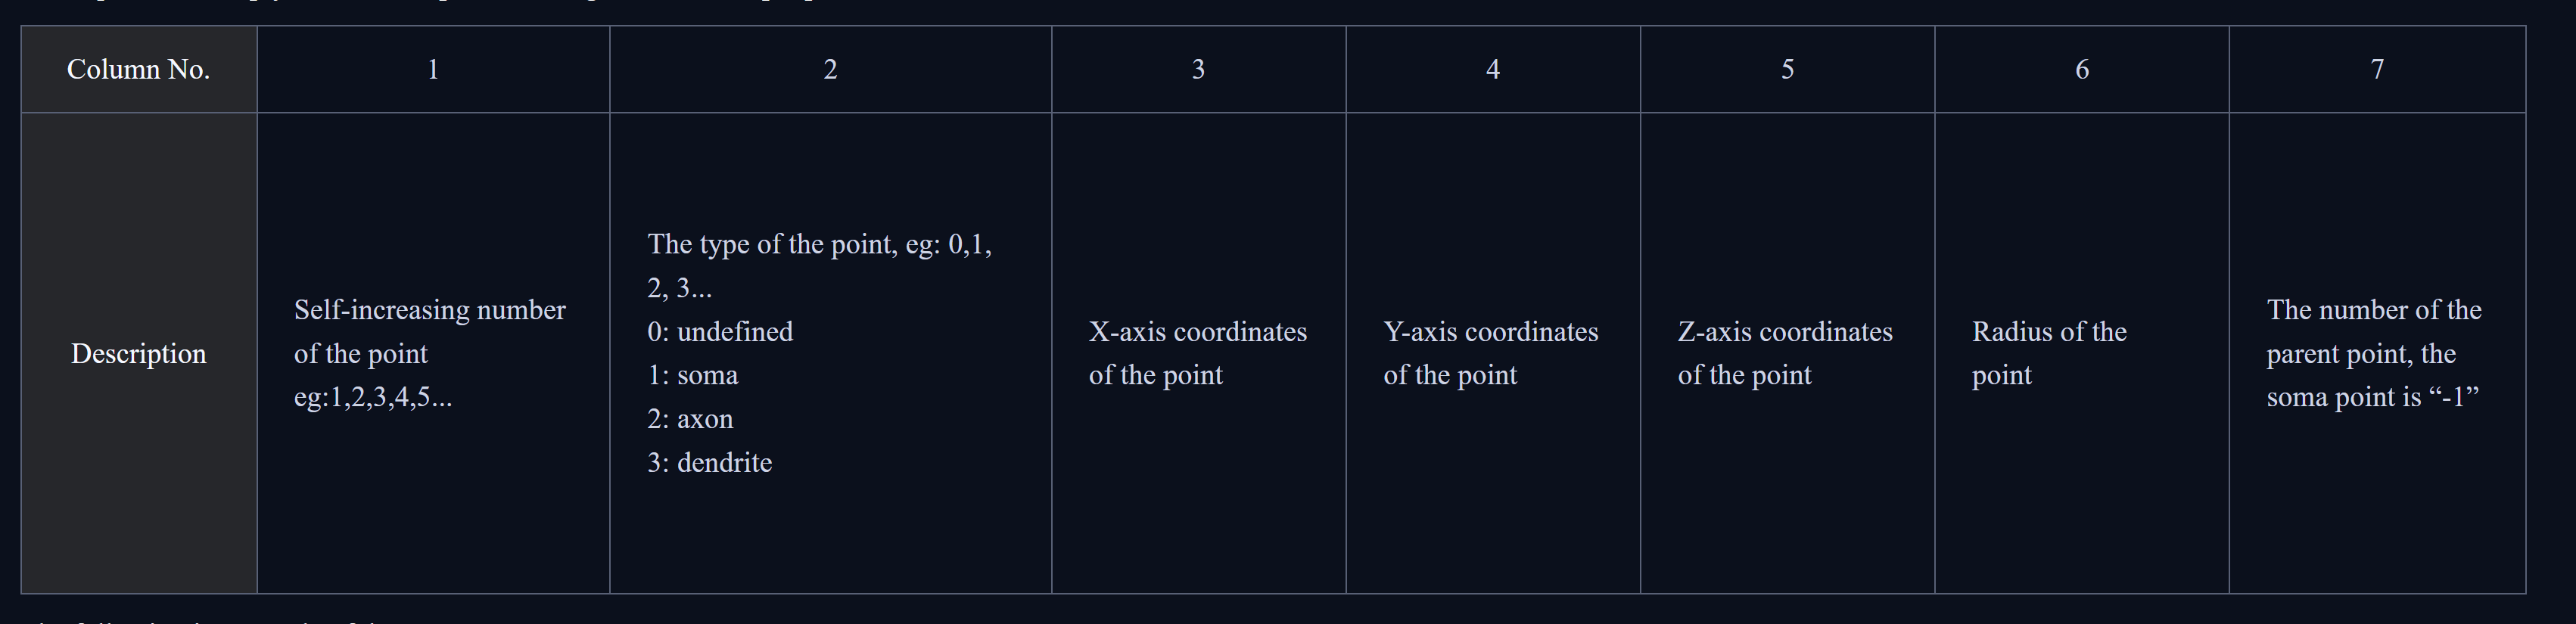